# 01 - Data Acquisition, Cleaning & EDA

Heart Disease UCI (Cleveland) dataset. This notebook downloads the data, cleans it, and performs exploratory data analysis: missing-value analysis, class distribution, histograms, correlation heatmap, and feature relationship analysis.

## Setup

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
from src.data import load_raw, load_clean
from src.config import NUMERIC_FEATURES, CATEGORICAL_FEATURES, TARGET

## 1. Data acquisition
Run the download script (fetches `processed.cleveland.data` from the UCI repository and labels the columns).

In [2]:
!python ../data/download_data.py
raw = load_raw()
print('shape:', raw.shape)
raw.head()

Saved 303 rows to /home/ubuntu/heart-disease-mlops/data/heart_disease_raw.csv


shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 2. Missing value analysis
`ca` and `thal` use `?` as a missing marker in the raw UCI file.

In [3]:
(raw == '?').sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

## 3. Cleaning
- Replace `?` with NaN and coerce all columns to numeric.
- Binarize the target: original severity 0-4 -> 0 (no disease) / 1 (disease).

In [4]:
df = load_clean()
print('missing after coercion:')
print(df.isna().sum()[df.isna().sum() > 0])
df.describe().T

missing after coercion:
ca      4
thal    2
dtype: int64


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


## 4. Class distribution

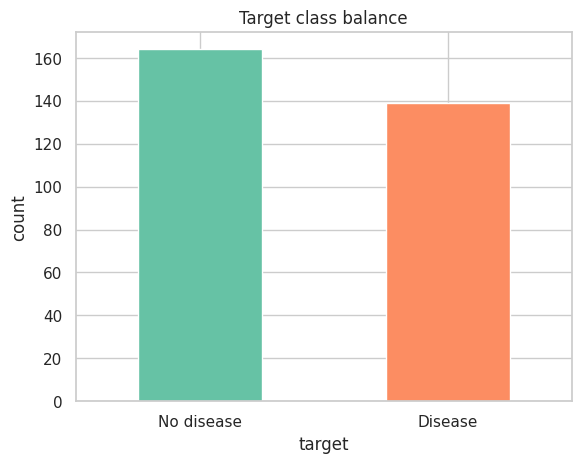

In [5]:
ax = df[TARGET].value_counts().sort_index().plot(kind='bar', color=['#66c2a5','#fc8d62'])
ax.set_xticklabels(['No disease','Disease'], rotation=0)
ax.set_title('Target class balance'); ax.set_ylabel('count'); plt.show()

## 5. Numeric feature histograms by target

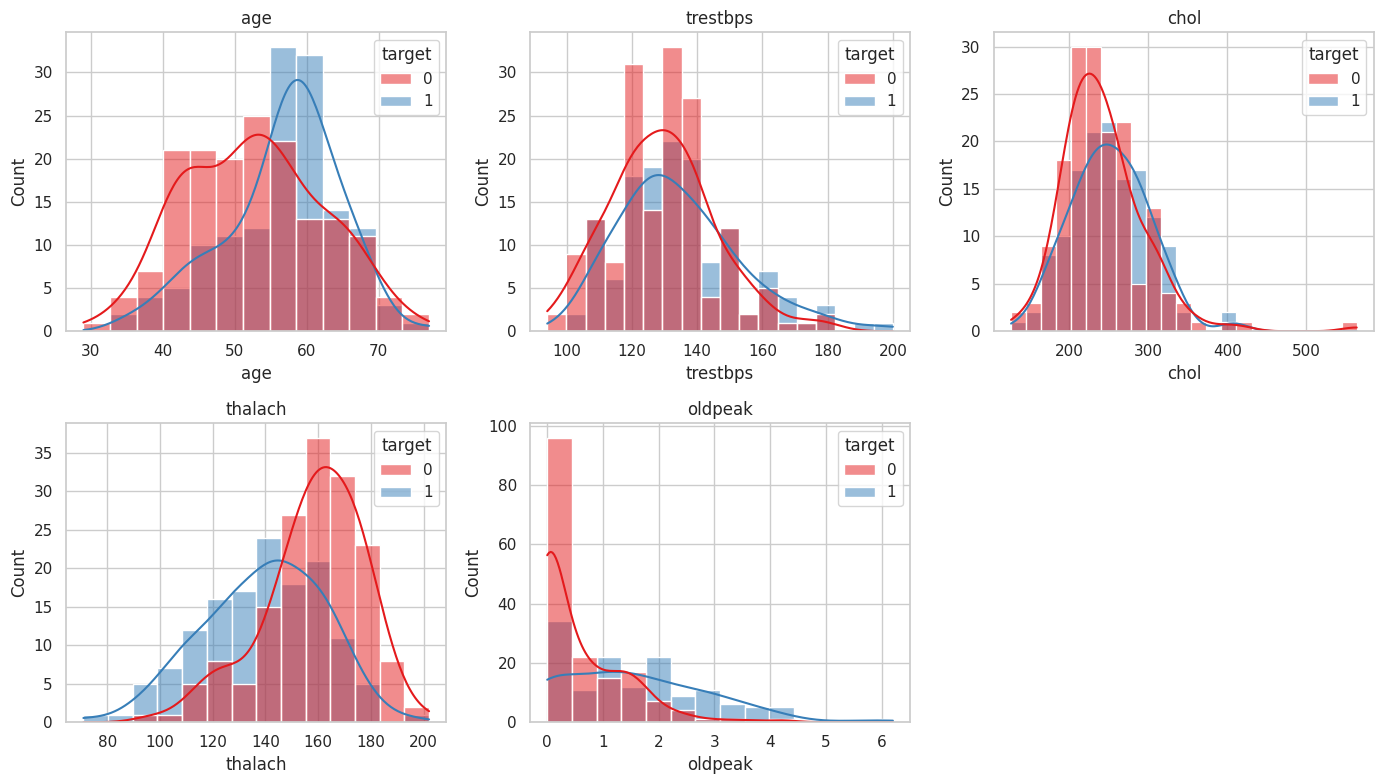

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.ravel(), NUMERIC_FEATURES):
    sns.histplot(data=df, x=col, hue=TARGET, kde=True, ax=ax, palette='Set1')
    ax.set_title(col)
for ax in axes.ravel()[len(NUMERIC_FEATURES):]:
    ax.axis('off')
plt.tight_layout(); plt.show()

## 6. Correlation heatmap

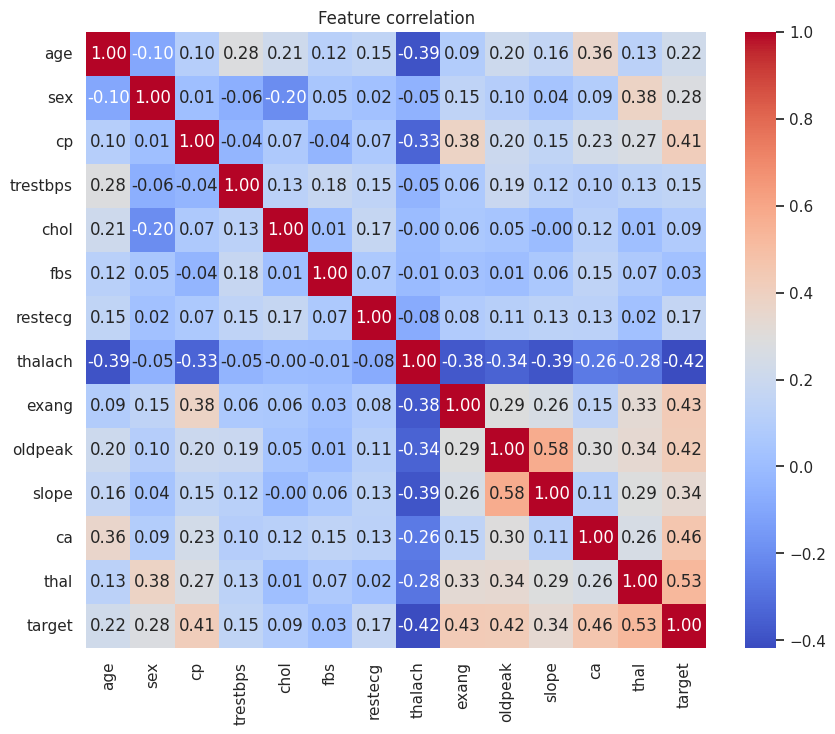

In [7]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature correlation'); plt.show()

## 7. Feature relationship analysis
Box plots of key numeric features vs. the target, and categorical relationships (chest-pain type, exercise-induced angina).

/tmp/ipykernel_7101/2493459980.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=TARGET, y=col, ax=ax, palette='Set2')
/tmp/ipykernel_7101/2493459980.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No disease','Disease']); ax.set_title(f'{col} vs target')
/tmp/ipykernel_7101/2493459980.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=TARGET, y=col, ax=ax, palette='Set2')
/tmp/ipykernel_7101/2493459980.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['

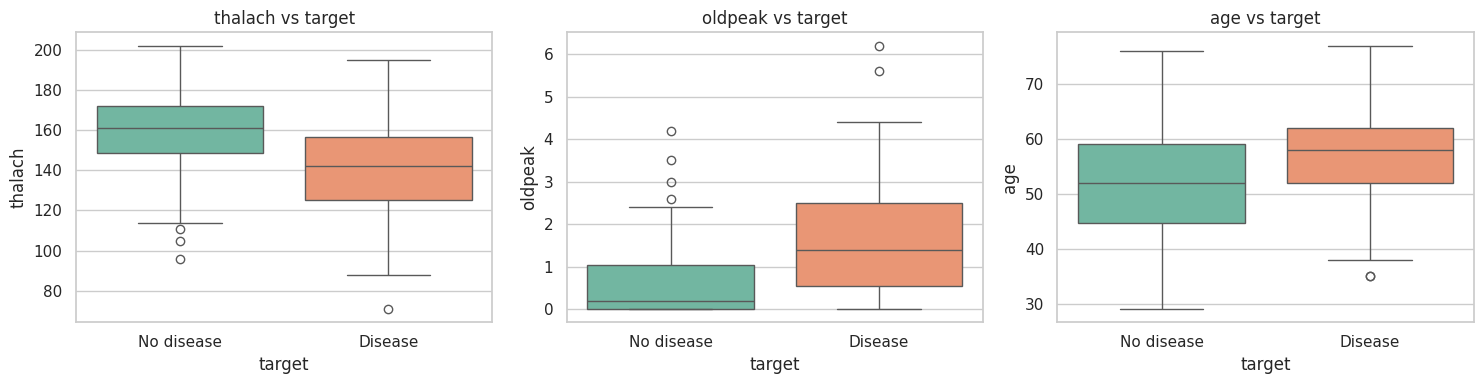

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['thalach', 'oldpeak', 'age']):
    sns.boxplot(data=df, x=TARGET, y=col, ax=ax, palette='Set2')
    ax.set_xticklabels(['No disease','Disease']); ax.set_title(f'{col} vs target')
plt.tight_layout(); plt.show()

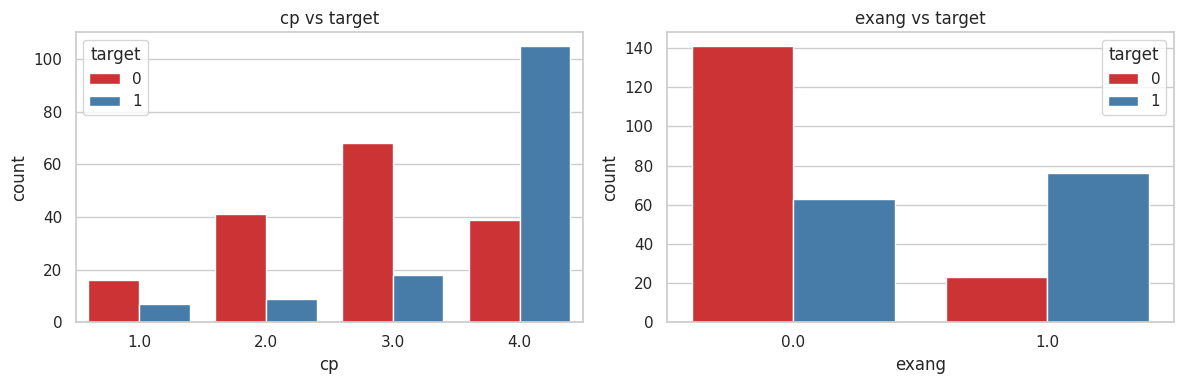

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ['cp', 'exang']):
    sns.countplot(data=df, x=col, hue=TARGET, ax=ax, palette='Set1')
    ax.set_title(f'{col} vs target')
plt.tight_layout(); plt.show()

**Observations:** classes are fairly balanced; lower `thalach` (max heart rate), higher `oldpeak`, and more affected vessels (`ca`) are associated with disease. Chest-pain type `cp` and exercise angina `exang` separate the classes well.